<a href="https://colab.research.google.com/github/jinbaaaaaang/poke-peek/blob/main/poke_peek_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 설치 및 데이터 다운로드

In [ ]:
import os, shutil
os.makedirs("data", exist_ok=True)

import kagglehub
path = kagglehub.dataset_download("lantian773030/pokemonclassification")
shutil.copytree(path, "data/PokemonData", dirs_exist_ok=True)
print("✅ data/PokemonData 준비 완료")

!pip install -q timm

Using Colab cache for faster access to the 'pokemonclassification' dataset.
✅ data/PokemonData 준비 완료


## Import

In [ ]:
import json
import os
import time
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import f1_score, precision_score, recall_score
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms

try:
    import timm   # ViT 사용을 위해 필요
    HAS_TIMM = True
except ImportError:
    HAS_TIMM = False
    print("⚠️  timm 없음 → ViT 실험 스킵. 설치: !pip install timm")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 설정

In [ ]:
CONFIG = {
    "data_dir"   : "data/PokemonData/PokemonData",
    "batch_size" : 32,
    "epochs"     : 30,
    "patience"   : 7,
    "val_ratio"  : 0.15,
    "test_ratio" : 0.15,
    "num_workers": 2,      # Colab 권장값
    "results_dir": "results",
    "seed"       : 42,
}

# ViT는 이미지 크기 224 고정 필요, 나머지도 224로 통일
IMAGE_SIZE = 224

EXPERIMENTS = [
    {
        "name"     : "Exp1_MobileNetV3",
        "backbone" : "mobilenet_v3_small",
        "lr"       : 1e-4,
        # 파라미터 ~2.5M — 가장 가벼움
        # 모바일/엣지 환경 대표 모델
    },
    {
        "name"     : "Exp2_ResNet50",
        "backbone" : "resnet50",
        "lr"       : 1e-4,
        # 파라미터 ~25M — 가장 검증된 중형 CNN
        # ResNet 계열의 강력한 baseline
    },
    {
        "name"     : "Exp3_EfficientNetB0",
        "backbone" : "efficientnet_b0",
        "lr"       : 1e-4,
        # 파라미터 ~4M — compound scaling으로 효율 극대화
        # 적은 파라미터로 ResNet50에 필적하는 성능
    },
    {
        "name"     : "Exp4_ViT_B16",
        "backbone" : "vit_b_16",
        "lr"       : 2e-5,   # ViT는 lr 더 낮게 (사전학습 구조 민감)
        # 파라미터 ~86M — CNN과 전혀 다른 self-attention 기반
        # 데이터 많을수록 유리하지만 pretrained이므로 소규모도 OK
    },
]

# timm 없으면 ViT 제외
if not HAS_TIMM:
    EXPERIMENTS = [e for e in EXPERIMENTS if e["backbone"] != "vit_b_16"]
    print("ViT 실험 제외됨")

## 데이터 로더

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def get_transforms():
    train_tf = transforms.Compose([
        transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
        transforms.RandomCrop(IMAGE_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2,
                               saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    val_tf = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    return train_tf, val_tf


def get_dataloaders():
    train_tf, val_tf = get_transforms()
    generator = torch.Generator().manual_seed(CONFIG["seed"])

    # 인덱스만 먼저 분리한 뒤, 각 subset에 transform을 따로 적용
    full_dataset = datasets.ImageFolder(CONFIG["data_dir"])
    n       = len(full_dataset)
    n_test  = int(n * CONFIG["test_ratio"])
    n_val   = int(n * CONFIG["val_ratio"])
    n_train = n - n_val - n_test

    idx       = torch.randperm(n, generator=generator).tolist()
    train_idx = idx[:n_train]
    val_idx   = idx[n_train:n_train + n_val]
    test_idx  = idx[n_train + n_val:]

    # transform을 subset별로 다르게 적용하는 커스텀 Dataset
    class TransformSubset(torch.utils.data.Dataset):
        def __init__(self, dataset, indices, transform):
            self.dataset   = dataset
            self.indices   = indices
            self.transform = transform
        def __len__(self):
            return len(self.indices)
        def __getitem__(self, i):
            path, label = self.dataset.imgs[self.indices[i]]
            from PIL import Image as PILImage
            img = PILImage.open(path).convert("RGB")
            return self.transform(img), label

    train_set = TransformSubset(full_dataset, train_idx, train_tf)
    val_set   = TransformSubset(full_dataset, val_idx,   val_tf)
    test_set  = TransformSubset(full_dataset, test_idx,  val_tf)

    kw = dict(batch_size=CONFIG["batch_size"],
              num_workers=CONFIG["num_workers"], pin_memory=True)
    train_loader = DataLoader(train_set, shuffle=True,  **kw)
    val_loader   = DataLoader(val_set,   shuffle=False, **kw)
    test_loader  = DataLoader(test_set,  shuffle=False, **kw)

    class_names = full_dataset.classes
    print(f"Classes : {len(class_names)}")
    print(f"Train {len(train_set)} | Val {len(val_set)} | Test {len(test_set)}")
    return train_loader, val_loader, test_loader, class_names

## 모델 빌더

In [ ]:
def build_model(backbone: str, num_classes: int) -> nn.Module:
    """
    모두 ImageNet pretrained + Full fine-tuning
    backbone별 특성:
      mobilenet_v3_small : 경량, 모바일 최적화
      resnet50           : 검증된 중형 CNN
      efficientnet_b0    : compound scaling, 효율적
      vit_b_16           : Vision Transformer (timm 필요)
    """
    if backbone == "mobilenet_v3_small":
        model = models.mobilenet_v3_small(weights="IMAGENET1K_V1")
        in_f  = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_f, num_classes)

    elif backbone == "resnet50":
        model = models.resnet50(weights="IMAGENET1K_V2")
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif backbone == "efficientnet_b0":
        model = models.efficientnet_b0(weights="IMAGENET1K_V1")
        in_f  = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.2), nn.Linear(in_f, num_classes))

    elif backbone == "vit_b_16":
        # timm의 ViT-B/16 사용 (torchvision ViT보다 유연)
        model = timm.create_model(
            "vit_base_patch16_224", pretrained=True,
            num_classes=num_classes)

    else:
        raise ValueError(f"Unknown backbone: {backbone}")

    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Params: {trainable:,} trainable / {total:,} total")
    return model

## 학습 & 평가

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        correct  += (out.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    loss_sum = correct = total = 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out  = model(imgs)
        loss = criterion(out, labels)
        loss_sum += loss.item() * imgs.size(0)
        preds    = out.argmax(1)
        correct  += (preds == labels).sum().item()
        total    += imgs.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return loss_sum / total, correct / total, all_preds, all_labels


def run_training(model, train_loader, val_loader, lr: float, save_path: str):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CONFIG["epochs"])

    history    = {"train_loss": [], "train_acc": [],
                  "val_loss":   [], "val_acc":   []}
    best_acc   = 0.0
    patience_c = 0
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)

    for epoch in range(1, CONFIG["epochs"] + 1):
        t0 = time.time()
        tr_loss, tr_acc          = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc, _, _    = evaluate(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)

        flag = ""
        if vl_acc > best_acc:
            best_acc = vl_acc; patience_c = 0
            torch.save(model.state_dict(), save_path)
            flag = " ✅"
        else:
            patience_c += 1
            if patience_c >= CONFIG["patience"]:
                print(f"  Early stop @ epoch {epoch}"); break

        print(f"  Ep[{epoch:3d}] "
              f"train {tr_loss:.4f}/{tr_acc:.4f} | "
              f"val {vl_loss:.4f}/{vl_acc:.4f} "
              f"({time.time()-t0:.1f}s){flag}")

    print(f"  Best val_acc: {best_acc:.4f}")
    return history


def compute_test_metrics(model, test_loader, checkpoint_path: str):
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    _, acc, preds, labels = evaluate(model, test_loader, nn.CrossEntropyLoss())
    return {
        "test_accuracy" : round(acc, 4),
        "test_precision": round(precision_score(labels, preds, average="macro", zero_division=0), 4),
        "test_recall"   : round(recall_score(   labels, preds, average="macro", zero_division=0), 4),
        "test_f1"       : round(f1_score(       labels, preds, average="macro", zero_division=0), 4),
    }

## 시각화

In [ ]:
COLORS = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]


def plot_learning_curve(history: dict, title: str, save_path: str):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ep = range(1, len(history["train_loss"]) + 1)

    ax1.plot(ep, history["train_loss"], label="Train")
    ax1.plot(ep, history["val_loss"],   label="Val")
    ax1.set(xlabel="Epoch", ylabel="Loss", title="Loss")
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(ep, history["train_acc"], label="Train")
    ax2.plot(ep, history["val_acc"],   label="Val")
    ax2.set(xlabel="Epoch", ylabel="Accuracy", title="Accuracy")
    ax2.legend(); ax2.grid(alpha=0.3)

    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_comparison(results: dict, save_path: str = "results/comparison.png"):
    metrics = ["test_accuracy", "test_precision", "test_recall", "test_f1"]
    labels  = list(results.keys())
    x, w    = np.arange(len(metrics)), 0.8 / len(labels)

    fig, ax = plt.subplots(figsize=(13, 6))
    for i, (name, res) in enumerate(results.items()):
        vals = [res[m] for m in metrics]
        bars = ax.bar(x + i * w - (len(labels) - 1) * w / 2,
                      vals, w, label=name, color=COLORS[i], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("test_", "").capitalize() for m in metrics])
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Score")
    ax.set_title("Experiment Comparison — CNN vs Transformer",
                 fontsize=14, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def print_table(results: dict):
    cols = ["test_accuracy", "test_precision", "test_recall", "test_f1"]
    print(f"\n{'Experiment':<35}" + "".join(f"{c:>16}" for c in cols))
    print("─" * (35 + 16 * len(cols)))
    for name, res in results.items():
        print(f"{name:<35}" + "".join(f"{res[c]:>16.4f}" for c in cols))

## 메인 실행

In [ ]:
def main():
    os.makedirs(CONFIG["results_dir"], exist_ok=True)

    print("📂 데이터 로딩 중...")
    train_loader, val_loader, test_loader, class_names = get_dataloaders()
    num_classes = len(class_names)

    with open(f"{CONFIG['results_dir']}/class_names.json", "w") as f:
        json.dump(class_names, f, indent=2)

    all_results   = {}
    all_histories = {}

    for cfg in EXPERIMENTS:
        name = cfg["name"]
        print(f"\n{'═'*60}")
        print(f"  🚀 {name}  (backbone={cfg['backbone']}, lr={cfg['lr']})")
        print(f"{'═'*60}")

        model     = build_model(cfg["backbone"], num_classes).to(DEVICE)
        ckpt_path = f"{CONFIG['results_dir']}/checkpoints/{name}.pth"

        history = run_training(model, train_loader, val_loader,
                               cfg["lr"], ckpt_path)
        metrics = compute_test_metrics(model, test_loader, ckpt_path)
        metrics["backbone"] = cfg["backbone"]

        all_results[name]   = metrics
        all_histories[name] = history

        plot_learning_curve(history, title=name,
                            save_path=f"{CONFIG['results_dir']}/curves/{name}.png")

        with open(f"{CONFIG['results_dir']}/{name}_metrics.json", "w") as f:
            json.dump(metrics, f, indent=2)

        print(f"  Test → acc={metrics['test_accuracy']:.4f} | "
              f"f1={metrics['test_f1']:.4f}")

    print_table(all_results)
    plot_comparison(all_results)

    with open(f"{CONFIG['results_dir']}/all_results.json", "w") as f:
        json.dump(all_results, f, indent=2)

    print(f"\n✅ 완료!")
    return all_results, all_histories, class_names


all_results, all_histories, class_names = main()

📂 데이터 로딩 중...
Classes : 150
Train 4774 | Val 1023 | Test 1023

════════════════════════════════════════════════════════════
  🚀 Exp1_MobileNetV3  (backbone=mobilenet_v3_small, lr=0.0001)
════════════════════════════════════════════════════════════
  Params: 1,671,606 trainable / 1,671,606 total
  Ep[  1] train 4.6816/0.0957 | val 3.9220/0.2874 (34.1s) ✅
  Ep[  2] train 2.9535/0.4786 | val 1.8806/0.6393 (33.7s) ✅
  Ep[  3] train 1.3273/0.7495 | val 0.9677/0.8006 (33.7s) ✅
  Ep[  4] train 0.7365/0.8511 | val 0.7222/0.8407 (33.4s) ✅
  Ep[  5] train 0.5225/0.8900 | val 0.5999/0.8592 (34.1s) ✅
  Ep[  6] train 0.3731/0.9225 | val 0.5320/0.8739 (33.3s) ✅
  Ep[  7] train 0.2949/0.9351 | val 0.4960/0.8700 (33.5s)
  Ep[  8] train 0.2278/0.9510 | val 0.4619/0.8759 (34.0s) ✅
  Ep[  9] train 0.1861/0.9623 | val 0.4383/0.8876 (34.0s) ✅
  Ep[ 10] train 0.1568/0.9682 | val 0.4378/0.8866 (33.6s)
  Ep[ 11] train 0.1360/0.9736 | val 0.4447/0.8847 (33.5s)
  Ep[ 12] train 0.1201/0.9744 | val 0.4289/0.8876 

100%|██████████| 20.5M/20.5M [00:00<00:00, 144MB/s]


  Params: 4,199,698 trainable / 4,199,698 total
  Ep[  1] train 4.6642/0.1349 | val 3.8939/0.3930 (34.0s) ✅
  Ep[  2] train 3.1674/0.5538 | val 2.2364/0.7253 (34.2s) ✅
  Ep[  3] train 1.7605/0.7922 | val 1.1751/0.8416 (33.9s) ✅
  Ep[  4] train 0.9565/0.8886 | val 0.7112/0.8895 (34.5s) ✅
  Ep[  5] train 0.5621/0.9323 | val 0.5107/0.9032 (34.4s) ✅
  Ep[  6] train 0.3793/0.9493 | val 0.4274/0.9081 (33.9s) ✅
  Ep[  7] train 0.2566/0.9692 | val 0.3558/0.9238 (33.9s) ✅
  Ep[  8] train 0.1984/0.9753 | val 0.3393/0.9296 (33.7s) ✅
  Ep[  9] train 0.1452/0.9832 | val 0.3176/0.9286 (34.2s)
  Ep[ 10] train 0.1256/0.9858 | val 0.3011/0.9267 (34.1s)
  Ep[ 11] train 0.0980/0.9883 | val 0.2954/0.9326 (33.9s) ✅
  Ep[ 12] train 0.0841/0.9902 | val 0.2811/0.9296 (34.2s)
  Ep[ 13] train 0.0685/0.9931 | val 0.2587/0.9345 (34.2s) ✅
  Ep[ 14] train 0.0623/0.9933 | val 0.2489/0.9384 (34.3s) ✅
  Ep[ 15] train 0.0578/0.9929 | val 0.2496/0.9404 (34.0s) ✅
  Ep[ 16] train 0.0524/0.9943 | val 0.2373/0.9453 (33.8s) 

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

  Params: 85,914,006 trainable / 85,914,006 total
  Ep[  1] train 3.4723/0.3014 | val 0.8826/0.8221 (210.5s) ✅
  Ep[  2] train 0.3725/0.9292 | val 0.3831/0.9150 (212.3s) ✅
  Ep[  3] train 0.1119/0.9788 | val 0.2741/0.9462 (211.8s) ✅
  Ep[  4] train 0.0559/0.9912 | val 0.2540/0.9501 (212.0s) ✅
  Ep[  5] train 0.0360/0.9933 | val 0.2664/0.9374 (211.7s)
  Ep[  6] train 0.0337/0.9927 | val 0.2168/0.9521 (211.8s) ✅
  Ep[  7] train 0.0253/0.9948 | val 0.2291/0.9482 (211.4s)
  Ep[  8] train 0.0254/0.9937 | val 0.2543/0.9404 (210.9s)
  Ep[  9] train 0.0247/0.9954 | val 0.2520/0.9335 (211.6s)
  Ep[ 10] train 0.0237/0.9946 | val 0.2334/0.9462 (210.6s)
  Ep[ 11] train 0.0219/0.9937 | val 0.2192/0.9521 (211.7s)
  Ep[ 12] train 0.0137/0.9958 | val 0.2096/0.9541 (212.6s) ✅
  Ep[ 13] train 0.0148/0.9964 | val 0.2088/0.9511 (211.5s)
  Ep[ 14] train 0.0131/0.9962 | val 0.2447/0.9413 (212.1s)
  Ep[ 15] train 0.0171/0.9954 | val 0.1950/0.9570 (212.1s) ✅
  Ep[ 16] train 0.0102/0.9966 | val 0.2070/0.9541 (

results/curves/Exp1_MobileNetV3.png


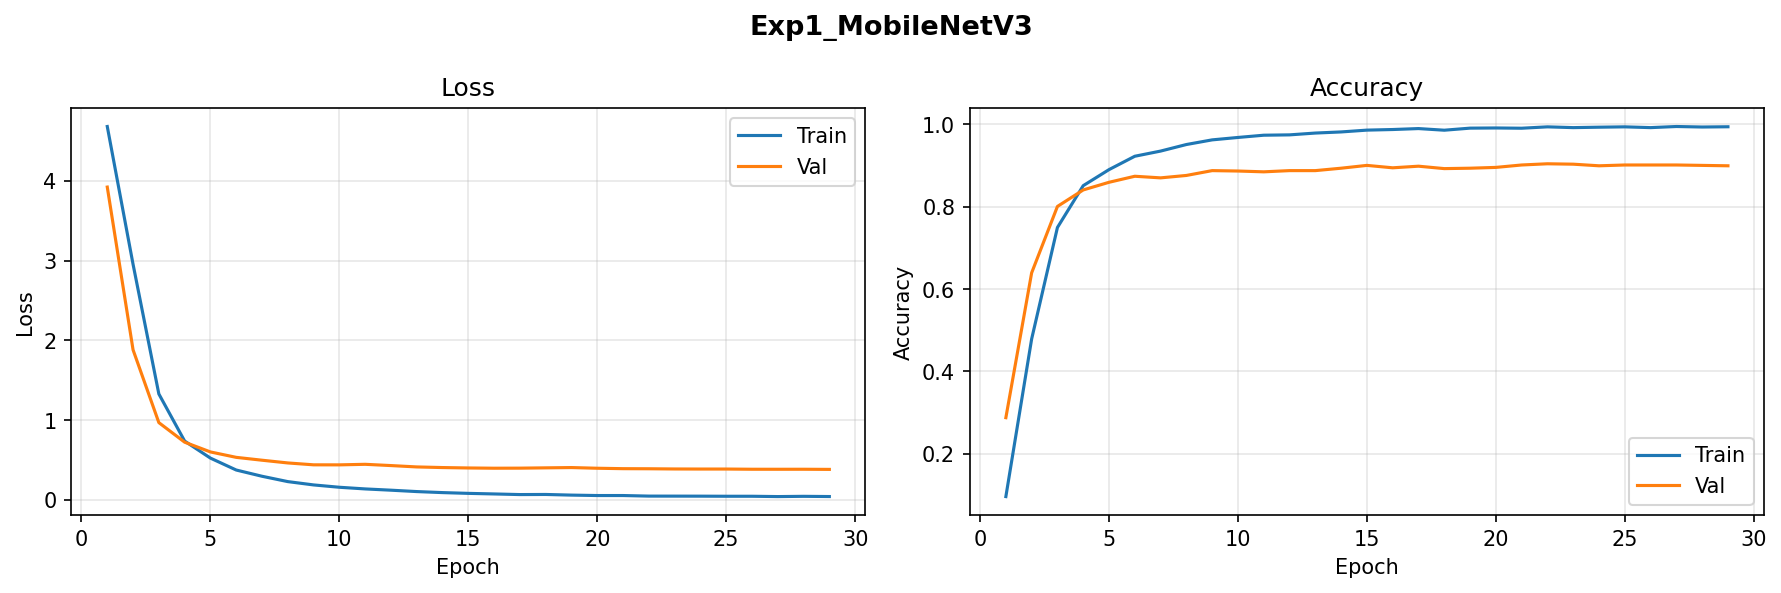

results/curves/Exp2_ResNet50.png


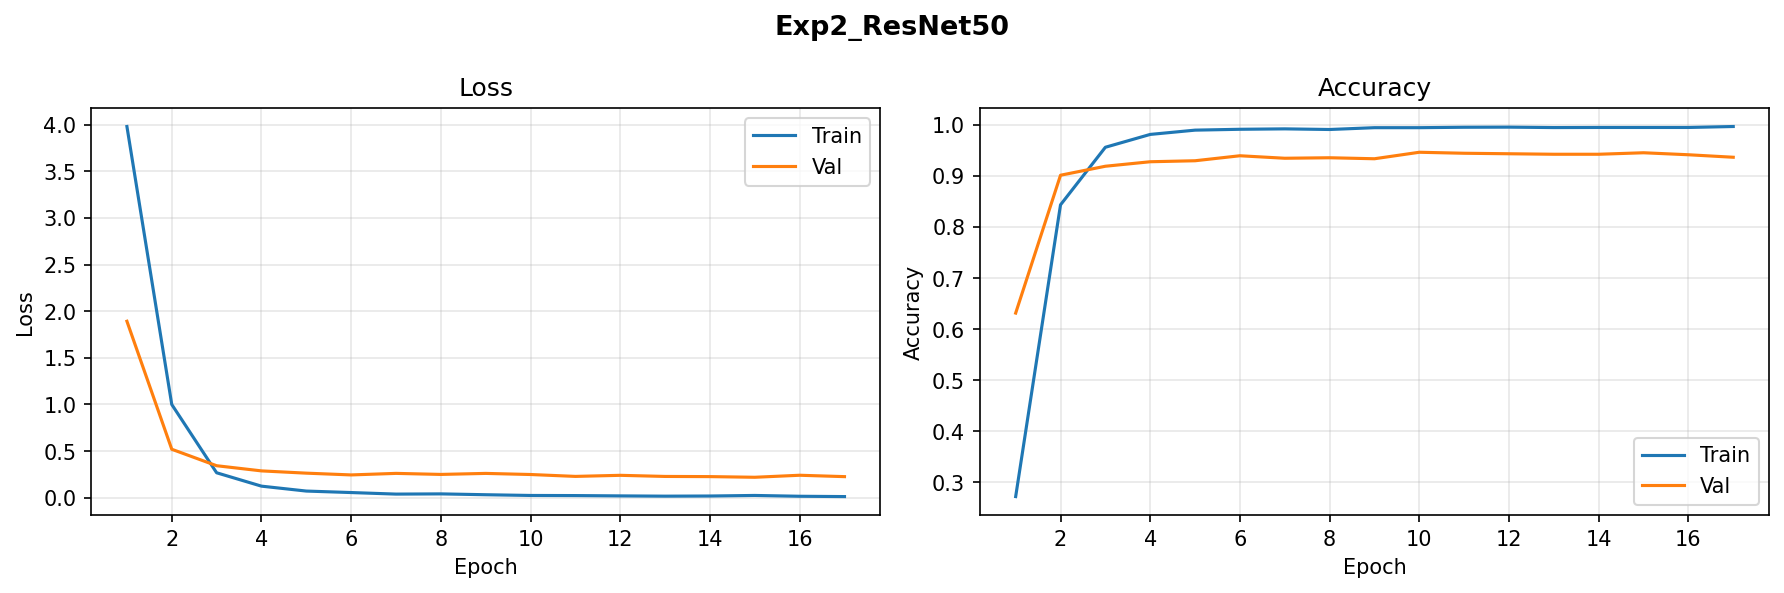

results/curves/Exp3_EfficientNetB0.png


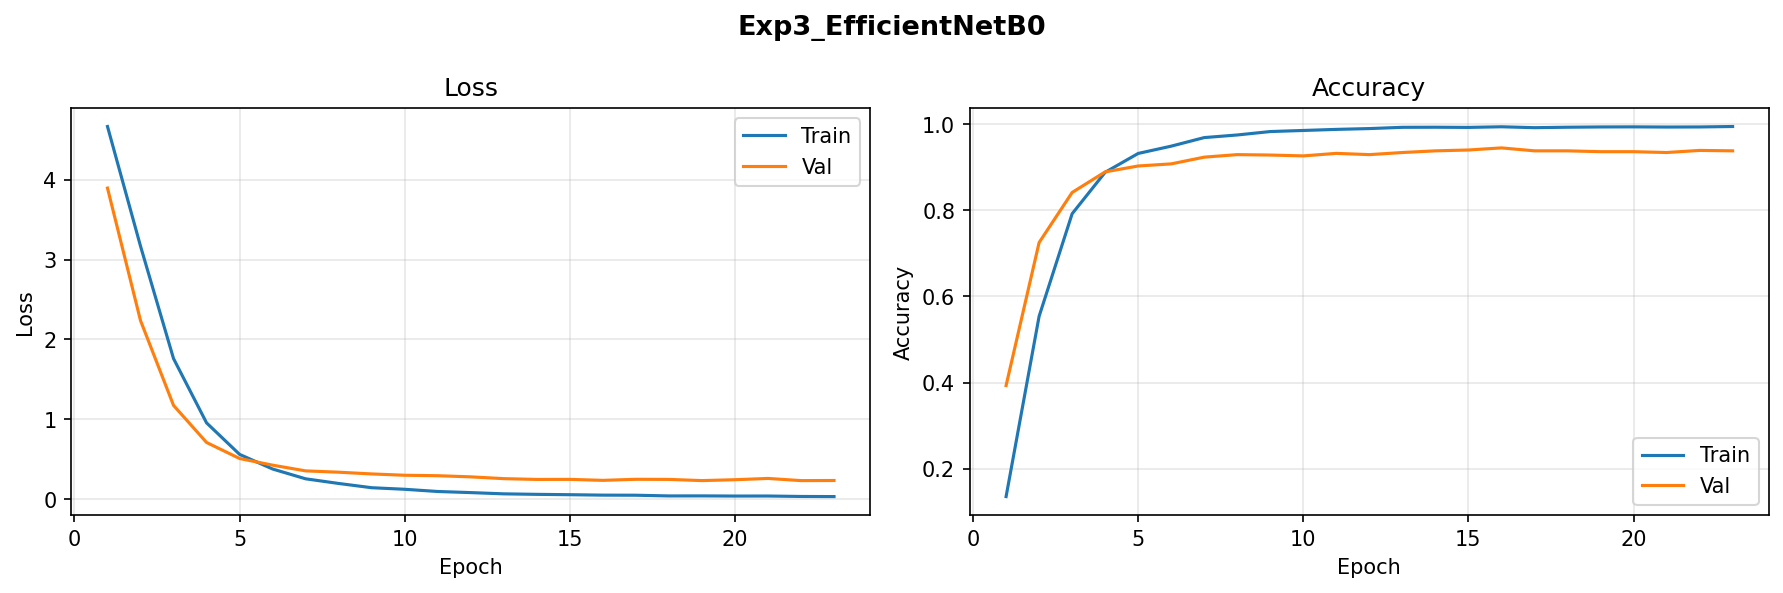

results/curves/Exp4_ViT_B16.png


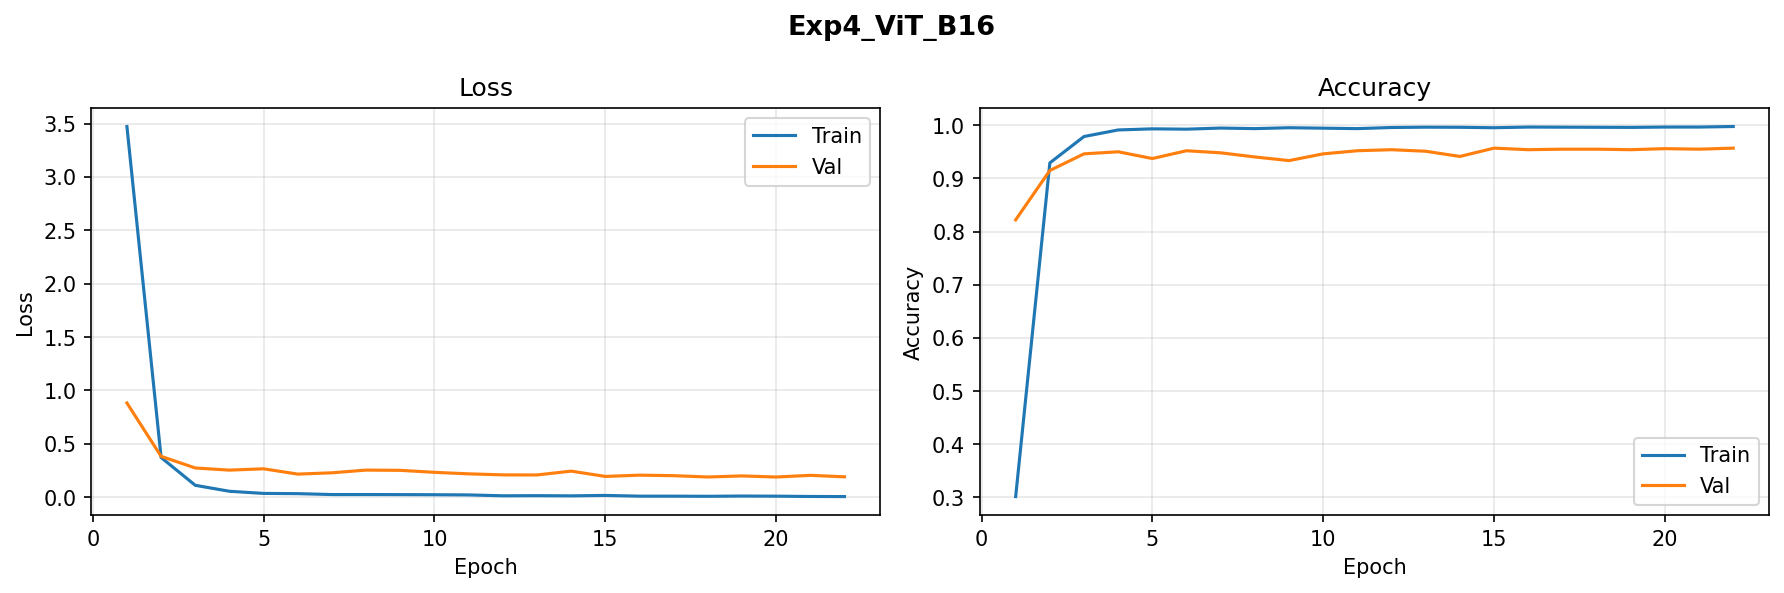

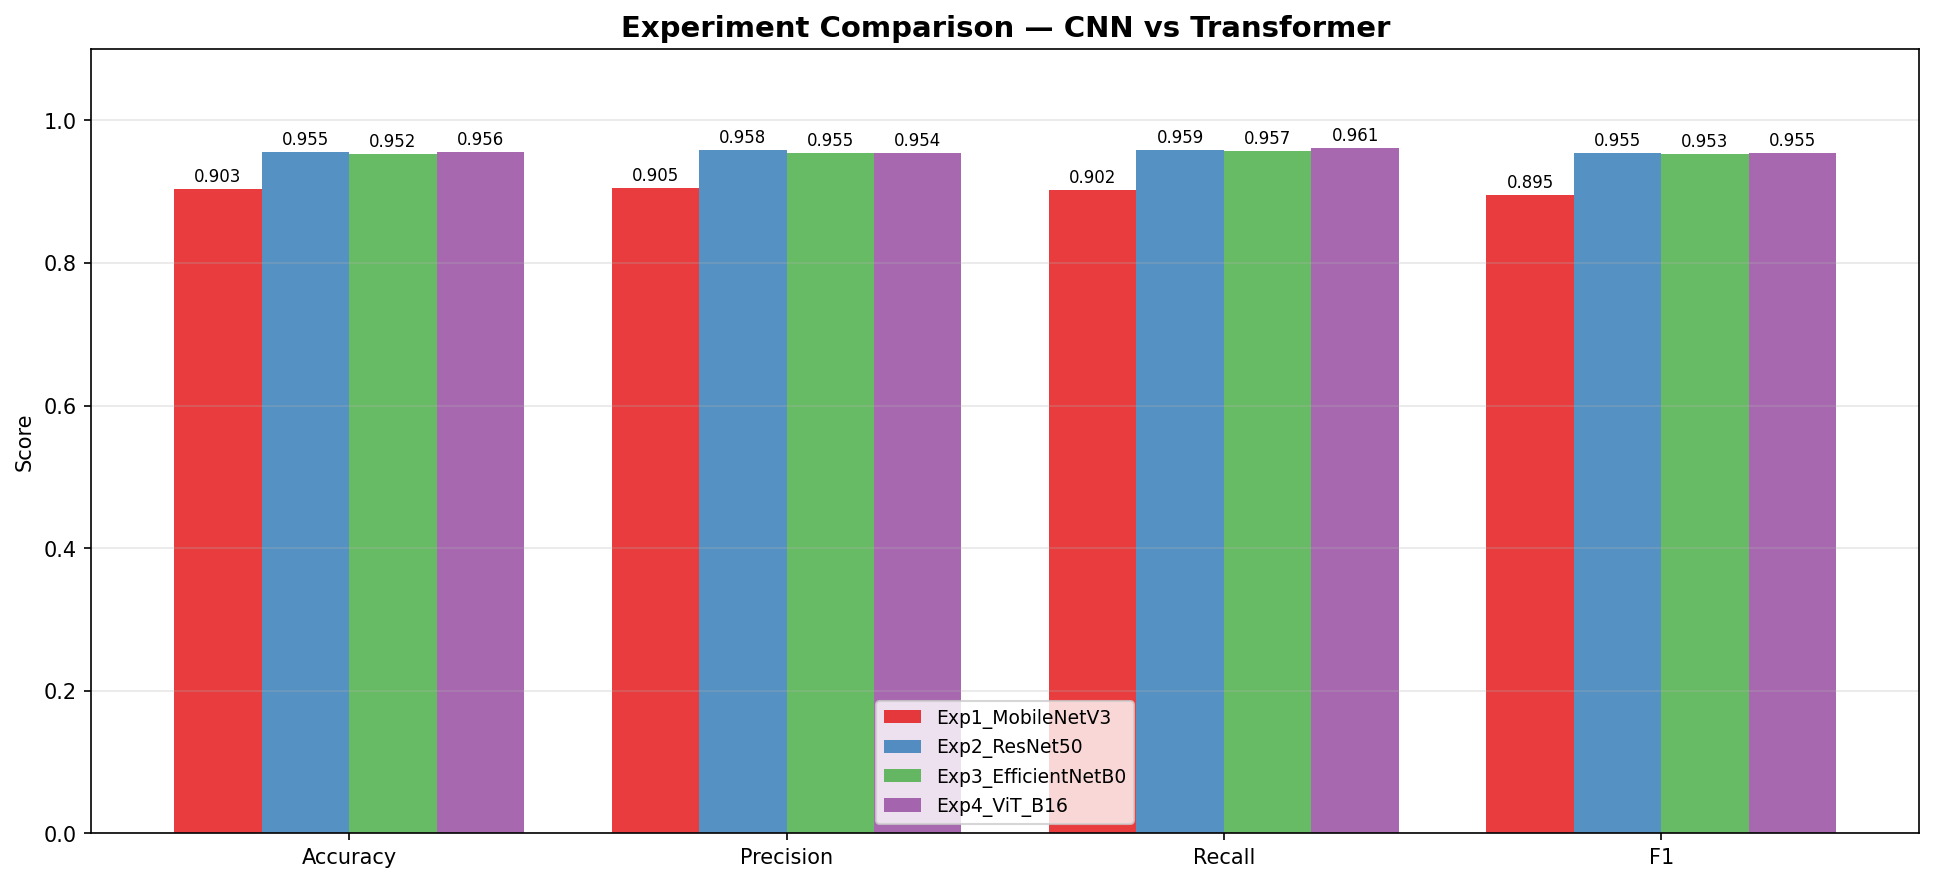

In [ ]:
from IPython.display import Image, display
import glob

# learning curve 전부 출력
for f in sorted(glob.glob("results/curves/*.png")):
    print(f)
    display(Image(f))

# 비교 차트
display(Image("results/comparison.png"))

## Streamlit 데모 파일 생성

In [ ]:
DEMO_CODE = 'import json, torch, torch.nn as nn, torch.nn.functional as F\nfrom io import BytesIO\nfrom pathlib import Path\nimport requests, streamlit as st\nfrom PIL import Image\nfrom torchvision import models, transforms\ntry:\n    import timm; HAS_TIMM = True\nexcept ImportError:\n    HAS_TIMM = False\n\nIMAGENET_MEAN=[0.485,0.456,0.406]\nIMAGENET_STD=[0.229,0.224,0.225]\nIMAGE_SIZE=224\nC1="#FFFEF9"; C2="#FFFDF5"; C3="#F0E8D5"; PINK="#F0C8CC"; DPINK="#C2185B"; TXT="#3D2B1F"; MTXT="#C0A070"\n\nEXP_MAP={\n    "Exp1: MobileNetV3-Small":("Exp1_MobileNetV3","mobilenet_v3_small"),\n    "Exp2: ResNet-50":("Exp2_ResNet50","resnet50"),\n    "Exp3: EfficientNet-B0":("Exp3_EfficientNetB0","efficientnet_b0"),\n    "Exp4: ViT-B/16":("Exp4_ViT_B16","vit_b_16"),\n}\n\ndef build_model(backbone,num_classes):\n    if backbone=="mobilenet_v3_small":\n        m=models.mobilenet_v3_small(weights=None)\n        m.classifier[3]=nn.Linear(m.classifier[3].in_features,num_classes)\n    elif backbone=="resnet50":\n        m=models.resnet50(weights=None)\n        m.fc=nn.Linear(m.fc.in_features,num_classes)\n    elif backbone=="efficientnet_b0":\n        m=models.efficientnet_b0(weights=None)\n        m.classifier=nn.Sequential(nn.Dropout(0.2),nn.Linear(m.classifier[1].in_features,num_classes))\n    elif backbone=="vit_b_16" and HAS_TIMM:\n        m=timm.create_model("vit_base_patch16_224",pretrained=False,num_classes=num_classes)\n    else: raise ValueError(f"Unknown: {backbone}")\n    return m\n\n@st.cache_resource\ndef load_model(exp_name,backbone,num_classes):\n    device=torch.device("cuda" if torch.cuda.is_available() else "cpu")\n    m=build_model(backbone,num_classes)\n    m.load_state_dict(torch.load(f"results/checkpoints/{exp_name}.pth",map_location=device))\n    return m.to(device).eval(),device\n\n@st.cache_data\ndef load_classes():\n    with open("results/class_names.json") as f: return json.load(f)\n\ndef preprocess(img):\n    tf=transforms.Compose([transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),\n        transforms.ToTensor(),transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)])\n    return tf(img.convert("RGB")).unsqueeze(0)\n\nst.set_page_config(page_title="PokeClassifier",page_icon="🌸",layout="wide")\nst.markdown(f"<style>[data-testid=stAppViewContainer]{{background:{C1}}}[data-testid=stSidebar]{{background:{C2}!important}}</style>",unsafe_allow_html=True)\nst.markdown(f\'<div style="background:{C2};border:1.5px solid {C3};padding:1.5rem;border-radius:20px;text-align:center;margin-bottom:1rem">\'\n            f\'<div style="font-size:2rem">🌸</div>\'\n            f\'<div style="color:{TXT};font-size:1.8rem;font-weight:800;margin:0">PokeClassifier</div>\'\n            f\'<div style="color:{MTXT};font-size:.9rem;margin-top:.2rem">포켓몬 사진을 올리면 AI가 이름을 알아맞혀줘요!</div>\'\n            f\'</div>\',unsafe_allow_html=True)\n\nclass_names=load_classes()\n\nwith st.sidebar:\n    st.markdown(f\'<p style="color:{MTXT};font-weight:700">🔍 모델 선택</p>\',unsafe_allow_html=True)\n    choice=st.selectbox("",list(EXP_MAP.keys()),index=1)\n    exp_name,backbone=EXP_MAP[choice]\n    if backbone=="vit_b_16" and not HAS_TIMM: st.error("timm 필요!"); st.stop()\n    try:\n        with st.spinner("로딩 중..."):\n            model,device=load_model(exp_name,backbone,len(class_names))\n        st.success("✅ 준비 완료!")\n        if Path("results/all_results.json").exists():\n            with open("results/all_results.json") as f: res=json.load(f).get(exp_name,{})\n            if res:\n                st.markdown("---")\n                st.markdown("**📊 성적표**")\n                c1,c2=st.columns(2)\n                c1.metric("정확도",f"{res[\'test_accuracy\']:.1%}")\n                c2.metric("F1",f"{res[\'test_f1\']:.1%}")\n                c1.metric("정밀도",f"{res[\'test_precision\']:.1%}")\n                c2.metric("재현율",f"{res[\'test_recall\']:.1%}")\n    except FileNotFoundError: st.error("모델 없음! 학습 먼저!"); st.stop()\n\nL,R=st.columns([1,1],gap="large")\nwith L:\n    t1,t2=st.tabs(["📁 사진 올리기","🔗 URL"])\n    image=None\n    with t1:\n        up=st.file_uploader("",type=["jpg","jpeg","png","webp"])\n        if up: image=Image.open(up).convert("RGB")\n    with t2:\n        url=st.text_input("",placeholder="https://...")\n        if url:\n            try: image=Image.open(BytesIO(requests.get(url,timeout=8).content)).convert("RGB")\n            except: st.error("❌ 불러오기 실패")\n    if image: st.image(image,use_column_width=True)\n    else: st.markdown(f\'<div style="text-align:center;padding:3rem;font-size:3rem">🌸</div>\',unsafe_allow_html=True)\n\nwith R:\n    if image is None:\n        st.markdown(f\'<div style="text-align:center;padding:4rem;color:{MTXT}"><div style="font-size:3rem">🌸</div><p>왼쪽에 이미지를 올려주세요!</p></div>\',unsafe_allow_html=True)\n    else:\n        with st.spinner("🔍 분석 중..."):\n            with torch.no_grad():\n                probs=F.softmax(model(preprocess(image).to(device)),dim=1)[0]\n        top_p,top_idx=torch.topk(probs,5)\n        n1,c1val=class_names[top_idx[0]],top_p[0].item()\n        st.markdown(f\'<div style="background:{C2};border:2px solid {PINK};border-radius:16px;padding:1.2rem;text-align:center;margin-bottom:.8rem">\'\n                    f\'<div style="font-size:1.5rem">🏆</div>\'\n                    f\'<div style="font-size:1.4rem;font-weight:800;color:{TXT}">{n1}</div>\'\n                    f\'<div style="background:{PINK};display:inline-block;padding:.15rem .8rem;border-radius:99px;font-size:.85rem;color:{DPINK};font-weight:700;margin-top:.3rem">신뢰도 {c1val:.1%}</div>\'\n                    f\'</div>\',unsafe_allow_html=True)\n        st.markdown("**🌺 다른 후보들**")\n        medals=["🥈","🥉","4위","5위"]\n        for i,(idx,p) in enumerate(zip(top_idx[1:],top_p[1:]),0):\n            st.markdown(f"{medals[i]} **{class_names[idx]}** — {p.item():.1%}")\n            st.progress(p.item())\n'

with open("demo_app.py", "w") as f:
    f.write(DEMO_CODE.strip())

print("✅ demo_app.py 생성 완료!")
print("\n실행 방법:")
print("  로컬 : streamlit run demo_app.py")
print("  Colab: !streamlit run demo_app.py &")
print("         !npx localtunnel --port 8501")

✅ demo_app.py 생성 완료!

실행 방법:
  로컬 : streamlit run demo_app.py
  Colab: !streamlit run demo_app.py &
         !npx localtunnel --port 8501
